## TunedLens depth-routing figure

Four-panel figure showing how token predictions evolve across layers of `pythia-160m-deduped` on WikiText excerpts, using TunedLens probes.

- **(a)** Forward-KL heatmap for a single sequence: each cell shows the top predicted token at that layer/position; colour intensity = KL divergence from the final layer.
- **(b)** Cross-entropy trajectories across layers: mean ± 2σ over all tokens (blue) and the lowest-CE decile at layer 1 (purple).
- **(c)** Same as (b) but for forward KL divergence.
- **(d)** Histogram of the earliest layer at which each token's top prediction *persistently* matches the final layer for the remainder of the forward pass.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from transformers import AutoTokenizer

import depth_routing
from depth_routing.token_evolution_data_collect import load_tuned_lens_from_excerpts

# depth_routing is installed editably; the repo root is two levels above __init__.py
DATA_DIR = Path(depth_routing.__file__).parents[2] / "token_evolution_data"

trajectories, meta = load_tuned_lens_from_excerpts(DATA_DIR)
layer_labels = meta["layer_labels"]
model_name = meta["model_name"]
n_layers_plus_one = len(layer_labels)
print(f"Loaded {len(trajectories)} trajectories, model: {model_name} ({n_layers_plus_one - 1} layers)")

/Users/yuchenli/Documents/depth-routing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

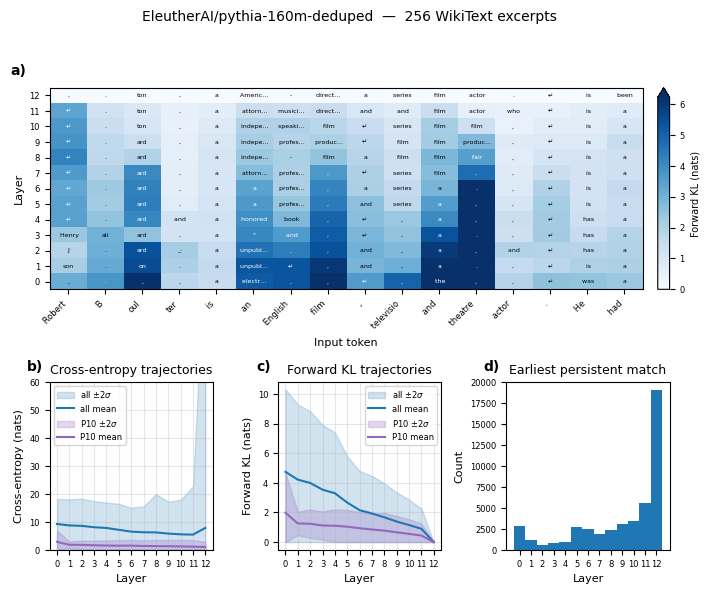

In [2]:
MAX_DISPLAY_TOKENS  = 16   # columns shown in panel (a)
EARLY_LAYER_CUTOFF  = 6    # threshold used to pick the example sequence

tokenizer = AutoTokenizer.from_pretrained(model_name)
x = np.arange(n_layers_plus_one)

# Persistent earliest-match per token
# persistent_earliest[p] = first layer l where top[l:] all equal top[-1]
all_persistent = []
for t in trajectories:
    top  = np.asarray(t["top_token_ids"])          # (n_layers+1, seq_len)
    cum  = np.cumprod((top == top[-1:])[::-1], axis=0)[::-1]
    all_persistent.append(np.argmax(cum, axis=0))

# Panel (a): pick a sequence where some tokens stabilise early 
best_idx = next(
    (ti for ti, t in enumerate(trajectories)
     if np.any(all_persistent[ti][:MAX_DISPLAY_TOKENS] <= EARLY_LAYER_CUTOFF)),
    min(range(len(trajectories)),
        key=lambda ti: all_persistent[ti][:MAX_DISPLAY_TOKENS].min()),
)

traj_a  = trajectories[best_idx]
seq_a   = min(MAX_DISPLAY_TOKENS, len(traj_a["input_ids"]))
top_ids = np.asarray(traj_a["top_token_ids"])[:, :seq_a]     # (n_layers+1, seq_a)
fkl_grid = np.asarray(traj_a["forward_kl"], dtype=np.float32)[:, :seq_a]

token_grid = np.empty_like(top_ids, dtype=object)
for l in range(n_layers_plus_one):
    for s in range(seq_a):
        tok = tokenizer.decode([int(top_ids[l, s])]).replace("\n", "↵")
        token_grid[l, s] = tok[:8] if len(tok) <= 8 else tok[:7] + "…"

# ── Panels (b) & (c): per-token CE and KL trajectory arrays ──────────────────
all_ce_trajs  = np.vstack([t["cross_entropy"].T.astype(np.float32) for t in trajectories])
all_fkl_trajs = np.vstack([t["forward_kl"].T.astype(np.float32)   for t in trajectories])

ce_mean,  ce_std  = all_ce_trajs.mean(0),  all_ce_trajs.std(0)
fkl_mean, fkl_std = all_fkl_trajs.mean(0), all_fkl_trajs.std(0)

# Bottom-10% by CE/KL at layer 1 ("early-stabilising" tokens)
l1      = min(1, n_layers_plus_one - 1)
n_p10   = max(1, len(all_ce_trajs) // 10)
ce_p10  = all_ce_trajs [np.argsort(all_ce_trajs [:, l1])[:n_p10]]
fkl_p10 = all_fkl_trajs[np.argsort(all_fkl_trajs[:, l1])[:n_p10]]
ce_p10_mean,  ce_p10_std  = ce_p10.mean(0),  ce_p10.std(0)
fkl_p10_mean, fkl_p10_std = fkl_p10.mean(0), fkl_p10.std(0)

fig = plt.figure(figsize=(8, 6))
gs  = GridSpec(2, 3, figure=fig, height_ratios=[1.2, 1], hspace=0.5, wspace=0.4)
ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])
ax_d = fig.add_subplot(gs[1, 2])

for ax, label in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c"), (ax_d, "d")]:
    ax.text(-0.04, 1.05, f"{label})", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="bottom", ha="right")

# (a) Forward-KL heatmap with predicted tokens overlaid
vmax = float(np.percentile(fkl_grid, 95))
im   = ax_a.imshow(fkl_grid, aspect="auto", origin="lower",
                   cmap="Blues", norm=Normalize(vmin=0, vmax=vmax))
thresh = float(np.percentile(fkl_grid, 75))
for l in range(n_layers_plus_one):
    for s in range(seq_a):
        ax_a.text(s, l, token_grid[l, s], ha="center", va="center", fontsize=4.5,
                  color="white" if fkl_grid[l, s] > thresh else "black")
ax_a.set_xticks(np.arange(seq_a))
ax_a.set_xticklabels(
    [traj_a["token_strings"][i].replace("\n", "↵")[:10] for i in range(seq_a)],
    rotation=45, ha="right", fontsize=6)
ax_a.set_yticks(np.arange(n_layers_plus_one))
ax_a.set_yticklabels(range(n_layers_plus_one), fontsize=6)
ax_a.set_xlabel("Input token", fontsize=8)
ax_a.set_ylabel("Layer", fontsize=8)
divider = make_axes_locatable(ax_a)
cax = divider.append_axes("right", size="2%", pad=0.15)
cbar = fig.colorbar(im, cax=cax, extend="max")
cbar.set_label("Forward KL (nats)", fontsize=7)
cbar.ax.tick_params(labelsize=6)

# (b) Cross-entropy across layers
ax_b.fill_between(x, np.maximum(ce_mean - 2*ce_std, 0), ce_mean + 2*ce_std,
                  alpha=0.2, color="C0", label=r"all $\pm2\sigma$")
ax_b.plot(x, ce_mean, lw=1.5, color="C0", label="all mean")
ax_b.fill_between(x, np.maximum(ce_p10_mean - 2*ce_p10_std, 0), ce_p10_mean + 2*ce_p10_std,
                  alpha=0.25, color="tab:purple", label=r"P10 $\pm2\sigma$")
ax_b.plot(x, ce_p10_mean, lw=1.5, color="tab:purple", label="P10 mean")
ax_b.set_xlabel("Layer", fontsize=8); ax_b.set_ylabel("Cross-entropy (nats)", fontsize=8)
ax_b.set_ylim([0, 60]); ax_b.set_title("Cross-entropy trajectories", fontsize=9)
ax_b.legend(fontsize=6); ax_b.set_xticks(x); ax_b.set_xticklabels(range(n_layers_plus_one), fontsize=6)
ax_b.tick_params(axis="y", labelsize=6); ax_b.grid(True, alpha=0.3)

# (c) Forward KL across layers
ax_c.fill_between(x, np.maximum(fkl_mean - 2*fkl_std, 0), fkl_mean + 2*fkl_std,
                  alpha=0.2, color="C0", label=r"all $\pm2\sigma$")
ax_c.plot(x, fkl_mean, lw=1.5, color="C0", label="all mean")
ax_c.fill_between(x, np.maximum(fkl_p10_mean - 2*fkl_p10_std, 0), fkl_p10_mean + 2*fkl_p10_std,
                  alpha=0.25, color="tab:purple", label=r"P10 $\pm2\sigma$")
ax_c.plot(x, fkl_p10_mean, lw=1.5, color="tab:purple", label="P10 mean")
ax_c.set_xlabel("Layer", fontsize=8); ax_c.set_ylabel("Forward KL (nats)", fontsize=8)
ax_c.set_title("Forward KL trajectories", fontsize=9)
ax_c.legend(fontsize=6); ax_c.set_xticks(x); ax_c.set_xticklabels(range(n_layers_plus_one), fontsize=6)
ax_c.tick_params(axis="y", labelsize=6); ax_c.grid(True, alpha=0.3)

# (d) Persistent earliest-match histogram
ax_d.hist(np.concatenate(all_persistent), bins=np.arange(n_layers_plus_one + 1) - 0.5)
ax_d.set_xticks(x)
ax_d.set_xticklabels(range(n_layers_plus_one), fontsize=6)
ax_d.set_xlabel("Layer", fontsize=8)
ax_d.set_ylabel("Count", fontsize=8)
ax_d.set_title("Earliest persistent match", fontsize=9)
ax_d.tick_params(axis="y", labelsize=6)

fig.suptitle(f"{model_name}  —  {len(trajectories)} WikiText excerpts", fontsize=10, y=1.01)
plt.show()